In [190]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import DeconV as dv

In [191]:
true_proportions = pd.read_csv("../../../fimm/data/pbmc/true.csv", sep=",", index_col=0)
true_proportions = true_proportions.sort_index(axis="columns").sort_index(axis="rows")
true_proportions.index.name = None
true_proportions

,B cells,CD4 T,CD8 T,DCs,Monocytes,NK
36TS_PBMC,0.082933,0.229503,0.204228,0.012943,0.377872,0.092520
453W_PBMC,0.058854,0.287304,0.320502,0.010775,0.245667,0.076899
4DUY_PBMC,0.105722,0.320983,0.164215,0.009276,0.294850,0.104953
684C_PBMC,0.114487,0.341211,0.177874,0.014584,0.254811,0.097033
925L_PBMC,0.187059,0.231691,0.223318,0.007860,0.234494,0.115577
9JD4_PBMC,0.094967,0.343631,0.269980,0.010984,0.194281,0.086157
CR3L_PBMC,0.137329,0.330611,0.186336,0.016135,0.196571,0.133018
CYFZ_PBMC,0.098471,0.204259,0.327271,0.007765,0.197529,0.164706
CZJE_PBMC,0.148297,0.220536,0.169017,0.018178,0.262195,0.181776
FLWA_PBMC,0.102362,0.289034,0.102056,0.012963,0.255109,0.238477


In [192]:
cs_proportions = pd.read_table("3rd-party/cibersort/pbmc/cibersort_proportions.txt", index_col=0)
cs_proportions = cs_proportions.iloc[:, :-3]
cs_proportions = cs_proportions.sort_index(axis="columns").sort_index(axis="rows")
cs_proportions.index.name = None
cs_proportions

,B cells,CD4 T,CD8 T,DCs,Monocytes,NK
36TS_PBMC,0.137070,0.050768,0.018344,0.549573,0.202357,0.041889
453W_PBMC,0.151239,0.130906,0.028611,0.452511,0.136204,0.100529
4DUY_PBMC,0.175287,0.178268,0.025513,0.423806,0.166488,0.030637
684C_PBMC,0.224848,0.173707,0.000000,0.556151,0.010997,0.034298
925L_PBMC,0.249440,0.078249,0.029640,0.417969,0.154247,0.070455
9JD4_PBMC,0.142969,0.195823,0.053729,0.411825,0.141071,0.054583
CR3L_PBMC,0.215005,0.161844,0.000000,0.556874,0.029760,0.036517
CYFZ_PBMC,0.139130,0.113010,0.074562,0.524549,0.048510,0.100239
CZJE_PBMC,0.221375,0.095199,0.013108,0.603099,0.030240,0.036979
FLWA_PBMC,0.170120,0.159903,0.000000,0.428763,0.175798,0.065417


In [193]:
deconv_proportions = pd.read_csv("out/pbmc/nb/proportions_separate_bd.tsv", sep="\t", index_col=0)
deconv_proportions = deconv_proportions.sort_index(axis="columns").sort_index(axis="rows")
deconv_proportions

,B cells,CD4 T,CD8 T,DCs,Monocytes,NK
36TS_PBMC,0.015244,0.063618,0.130250,0.119905,0.557835,0.113147
453W_PBMC,0.018980,0.103670,0.175428,0.103920,0.421903,0.176100
4DUY_PBMC,0.024412,0.116709,0.178306,0.105339,0.420851,0.154383
684C_PBMC,0.023742,0.131454,0.146798,0.116288,0.441000,0.140718
925L_PBMC,0.030519,0.141833,0.155001,0.106119,0.428596,0.137932
9JD4_PBMC,0.025720,0.161097,0.174020,0.107744,0.367966,0.163452
CR3L_PBMC,0.030734,0.113267,0.118915,0.118271,0.473771,0.145042
CYFZ_PBMC,0.015193,0.127156,0.181907,0.121251,0.411733,0.142760
CZJE_PBMC,0.025818,0.111596,0.128914,0.142424,0.441329,0.149918
FLWA_PBMC,0.024182,0.116261,0.150437,0.138409,0.402210,0.168500


In [194]:
music_proportions = pd.read_csv("3rd-party/music/pbmc/music_proportions.csv", index_col=0)
music_proportions = music_proportions.sort_index(axis="columns").sort_index(axis="rows")
music_proportions.index.name = None
music_proportions

,B.cells,CD4.T,CD8.T,DCs,Monocytes,NK
CR3L_PBMC,0,0,0,0.006391,0.185958,0.807651
CYFZ_PBMC,0,0,0,0.000000,0.133587,0.866413
CZJE_PBMC,0,0,0,0.035314,0.140975,0.823711
FLWA_PBMC,0,0,0,0.042031,0.144699,0.813269
FY2H_PBMC,0,0,0,0.018007,0.197996,0.783997
G4YW_PBMC,0,0,0,0.020229,0.165344,0.814427
X36TS_PBMC,0,0,0,0.063756,0.220126,0.716118
X453W_PBMC,0,0,0,0.011702,0.126811,0.861488
X4DUY_PBMC,0,0,0,0.070702,0.104834,0.824464
X684C_PBMC,0,0,0,0.037561,0.105407,0.857032


In [195]:
scaden_proportions = pd.read_csv("3rd-party/scaden/pbmc/scaden_predictions.txt", sep="\t", index_col=0)
scaden_proportions.index = pd.read_csv("3rd-party/scaden/pbmc/data/pbmc_bulk_data.txt", sep="\t", index_col=0).columns
scaden_proportions = scaden_proportions.sort_index(axis="columns").sort_index(axis="rows")
scaden_proportions

,B cells,CD4 T,CD8 T,DCs,Monocytes,NK
36TS_PBMC,0.017381,0.470297,0.000214,0.080182,0.425823,0.006103
453W_PBMC,0.014767,0.587609,0.000246,0.074644,0.315981,0.006753
4DUY_PBMC,0.025851,0.642856,0.000159,0.054165,0.271183,0.005787
684C_PBMC,0.029279,0.616852,0.000177,0.059628,0.289836,0.004229
925L_PBMC,0.061919,0.599846,0.000272,0.058994,0.271836,0.007133
9JD4_PBMC,0.027964,0.648795,0.000181,0.076325,0.242242,0.004494
CR3L_PBMC,0.046924,0.592934,0.000111,0.080566,0.272846,0.006619
CYFZ_PBMC,0.028014,0.606618,0.000284,0.057267,0.299091,0.008726
CZJE_PBMC,0.043181,0.540885,0.000154,0.087141,0.319347,0.009292
FLWA_PBMC,0.023067,0.601046,0.000214,0.061403,0.305231,0.009039


In [196]:
melt = true_proportions.reset_index().melt(id_vars="index")
melt.rename(columns={"index": "sample", "value": "true", "variable":"cell_type"}, inplace=True)
melt["deconv"] = deconv_proportions.reset_index().melt(id_vars="index")["value"]
melt["scaden"] = scaden_proportions.reset_index().melt(id_vars="index")["value"]
melt["music"] = music_proportions.reset_index().melt(id_vars="index")["value"]
melt["cs"] = cs_proportions.reset_index().melt(id_vars="index")["value"]
melt

,sample,cell_type,true,deconv,scaden,music,cs
0,36TS_PBMC,B cells,0.082933,0.015244,0.017381,0.000000,0.137070
1,453W_PBMC,B cells,0.058854,0.018980,0.014767,0.000000,0.151239
2,4DUY_PBMC,B cells,0.105722,0.024412,0.025851,0.000000,0.175287
3,684C_PBMC,B cells,0.114487,0.023742,0.029279,0.000000,0.224848
4,925L_PBMC,B cells,0.187059,0.030519,0.061919,0.000000,0.249440
...,...,...,...,...,...,...,...
67,CYFZ_PBMC,NK,0.164706,0.142760,0.008726,0.861488,0.100239
68,CZJE_PBMC,NK,0.181776,0.149918,0.009292,0.824464,0.036979
69,FLWA_PBMC,NK,0.238477,0.168500,0.009039,0.857032,0.065417
70,FY2H_PBMC,NK,0.032445,0.092546,0.007454,0.794733,0.046298


In [197]:
def ccc(est, true):
    p = np.corrcoef(est, true)[0,1]
    mu_est = np.mean(est)
    mu_true = np.mean(true)
    s_est = np.std(est)
    s_true = np.std(true)

    return (2.0 * p * s_est * s_true) / (s_est**2 + s_true**2 + (mu_est - mu_true)**2)

p_deconv = np.corrcoef(melt["true"], melt["deconv"])[0,1]
p_scaden = np.corrcoef(melt["true"], melt["scaden"])[0,1]
p_music = np.corrcoef(melt["true"], melt["music"])[0,1]
p_cs = np.corrcoef(melt["true"], melt["cs"])[0,1]

ccc_deconv = ccc(melt["true"], melt["deconv"])
ccc_scaden = ccc(melt["true"], melt["scaden"])
ccc_music = ccc(melt["true"], melt["music"])
ccc_cs = ccc(melt["true"], melt["cs"])

print("DeconV: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_deconv, ccc_deconv))
print("SCADEN: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_scaden, ccc_scaden))
print("MuSiC: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_music, ccc_music))
print("CIBERSORT: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_cs, ccc_cs))

DeconV: Pearson correlation coefficient: 0.500, CCC: 0.485
SCADEN: Pearson correlation coefficient: 0.631, CCC: 0.500
MuSiC: Pearson correlation coefficient: -0.119, CCC: -0.076
CIBERSORT: Pearson correlation coefficient: -0.540, CCC: -0.492


In [198]:
df = true_proportions.reset_index().melt(id_vars="index")
df.rename(columns={"index": "sample", "value": "proportion", "variable":"cell_type"}, inplace=True)
df["type"] = "true"
df["error"] = None

melt["deconv_error"] = abs(melt["deconv"] - melt["true"])
melt["scaden_error"] = abs(melt["scaden"] - melt["true"])
melt["music_error"] = abs(melt["music"] - melt["true"])
melt["cs_error"] = abs(melt["cs"] - melt["true"])
melt["deconv_squared_error"] = melt["deconv_error"]**2
melt["scaden_squared_error"] = melt["scaden_error"]**2
melt["music_squared_error"] = melt["music_error"]**2
melt["cs_squared_error"] = melt["cs_error"]**2

temp = melt[["sample", "cell_type", "deconv", "deconv_error", "deconv_squared_error"]].rename(
    columns={"deconv": "proportion", "deconv_error": "error", "deconv_squared_error": "squared_error"}
)
temp["type"] = "deconv"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "scaden", "scaden_error", "scaden_squared_error"]].rename(
    columns={"scaden": "proportion", "scaden_error": "error", "scaden_squared_error": "squared_error"}
)
temp["type"] = "scaden"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "music", "music_error", "music_squared_error"]].rename(
    columns={"music": "proportion", "music_error": "error", "music_squared_error": "squared_error"}
)
temp["type"] = "music"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "cs", "cs_error", "cs_squared_error"]].rename(
    columns={"cs": "proportion", "cs_error": "error", "cs_squared_error": "squared_error"}
)
temp["type"] = "cs"
df = pd.concat([df, temp])

df

,sample,cell_type,proportion,type,error,squared_error
0,36TS_PBMC,B cells,0.082933,true,NaN,NaN
1,453W_PBMC,B cells,0.058854,true,NaN,NaN
2,4DUY_PBMC,B cells,0.105722,true,NaN,NaN
3,684C_PBMC,B cells,0.114487,true,NaN,NaN
4,925L_PBMC,B cells,0.187059,true,NaN,NaN
...,...,...,...,...,...,...
67,CYFZ_PBMC,NK,0.100239,cs,0.064467,0.004156
68,CZJE_PBMC,NK,0.036979,cs,0.144797,0.020966
69,FLWA_PBMC,NK,0.065417,cs,0.173059,0.029950
70,FY2H_PBMC,NK,0.046298,cs,0.013853,0.000192


/home/lutrarutra/.pyenv/versions/3.10.9/envs/lst/lib/python3.10/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:.25'` for same effect.
  warnings.warn(msg, FutureWarning)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


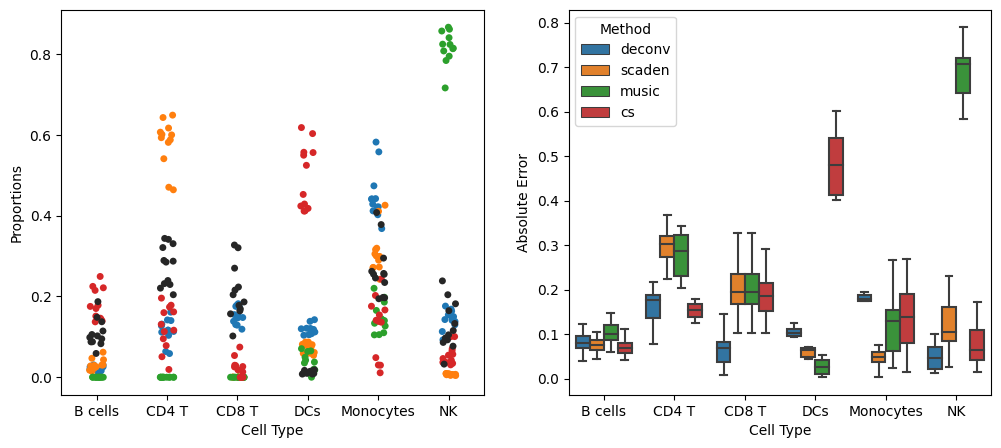

In [199]:
f, ax = plt.subplots(1,2, figsize=(12,5), dpi=100)

sns.stripplot(data=df[df["type"] != "true"], x="cell_type", y="proportion", hue="type", ax=ax[0])
sns.stripplot(data=df[df["type"] == "true"], x="cell_type", y="proportion", hue="type", ax=ax[0], color=".25")
plt.legend(title="Method")
sns.boxplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1], showfliers=False)

ax[0].set_ylabel("Proportions")
ax[1].set_ylabel("Absolute Error")
ax[0].set_xlabel("Cell Type")
ax[1].set_xlabel("Cell Type")
ax[0].get_legend().remove()
ax[1].get_legend().set_title("Method")

plt.savefig("comparison/pbmc/per_celltype.pdf", bbox_inches="tight")

plt.show()

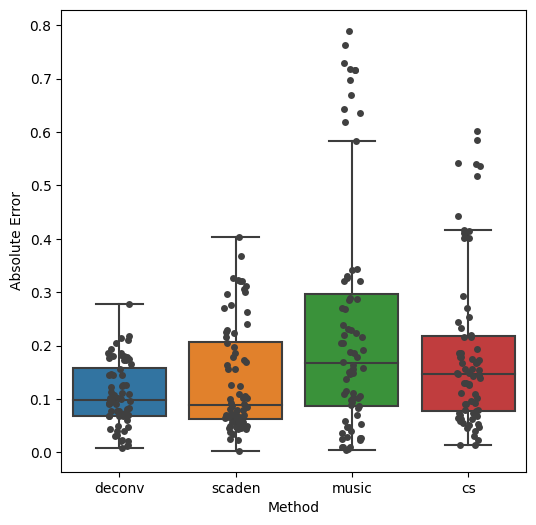

In [200]:
f, ax = plt.subplots(1, 1, figsize=(6,6), dpi=100)
sns.boxplot(data=df[df["type"] != "true"], y="error", x="type", showfliers=False, ax=ax)
sns.stripplot(data=df[df["type"] != "true"], x="type", y="error", ax=ax, color=".25")
ax.set_ylabel("Absolute Error")
ax.set_xlabel("Method")
plt.savefig("comparison/pbmc/box_abs_error.pdf", bbox_inches="tight")
plt.show()

In [201]:
df.groupby("type")[["error", "squared_error"]].mean()

,error,squared_error
type,,
cs,0.185803,0.056930
deconv,0.109030,0.015389
music,0.238589,0.106586
scaden,0.136417,0.028758
true,NaN,NaN
